<a href="https://colab.research.google.com/github/Rahamatunnisa1121/Object-Recognition-System/blob/main/preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import os  # To handle file and directory operations
import cv2  # OpenCV for image processing
import numpy as np  # NumPy for numerical computations
import tensorflow as tf  # TensorFlow for deep learning
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Keras tool for data augmentation
from matplotlib import pyplot as plt  # Matplotlib for visualization

In [ ]:
#load images from a folder and resize the images
def load_and_resize_images(folder_path,target_size=(128,128)):
  images=[] # List to store loaded images
  labels=[] # List to store corresponding labels
  for class_name in os.listdir(folder_path):
    class_path=os.path.join(folder_path,class_name)
    if not os.path.isdir(class_path): # Skip if it's not a folder
      continue
    # Iterate through each image in the category folder
    for img_name in os.listdir(class_path):
      img_path=os.path.join(class_path,img_name)
      img=cv2.imread(img_path) # Load the image using OpenCV
      if img is None: # Skip if the image can't be loaded
        continue
      img=cv2.resize(img,target_size) # Resize image to the target size (128x128)
      images.append(img) # Append resized image to the list
      labels.append(class_name)
  return np.array(images), np.array(labels) # Convert lists to NumPy arrays and return them


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path="/content/drive/MyDrive/vegetables_dataset" # to tell python where my dataset is located

In [ ]:
# Load and resize images for training, testing, and validation datasets
train_images, train_labels=load_and_resize_images(os.path.join(dataset_path,"train"))
test_images, test_labels=load_and_resize_images(os.path.join(dataset_path,"test"))
val_images, val_labels=load_and_resize_images(os.path.join(dataset_path,"validation"))

In [ ]:
#normalize images
train_images = train_images / 255.0
test_images = test_images / 255.0
val_images = val_images / 255.0

In [ ]:
def convert_to_grayscale(images):
    images_uint8 = (images * 255).astype(np.uint8)  # Convert float64 (0-1) to uint8 (0-255)
    return np.array([cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in images_uint8])  # Convert to grayscale

In [ ]:
# Apply grayscale conversion
train_gray = convert_to_grayscale(train_images)
test_gray = convert_to_grayscale(test_images)
val_gray = convert_to_grayscale(val_images)

In [ ]:

# Expand dimensions to match CNN input format (128, 128, 1)
train_gray = train_gray[..., np.newaxis]
test_gray = test_gray[..., np.newaxis]
val_gray = val_gray[..., np.newaxis]

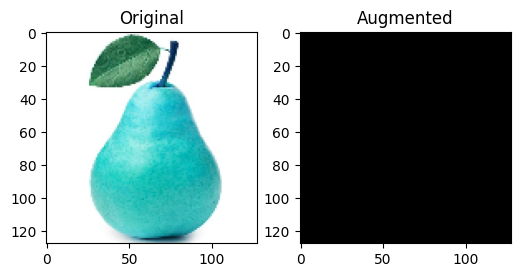

In [ ]:
#Data Augmentation for Generalization
datagen = ImageDataGenerator(
    rotation_range=30,   # Random rotation (0-30 degrees)
    width_shift_range=0.2,  # Random horizontal shift
    height_shift_range=0.2,  # Random vertical shift
    horizontal_flip=True,  # Flip images horizontally
    brightness_range=[0.8, 1.2],  # Adjust brightness
    zoom_range=0.2,  # Random zoom
    shear_range=0.2,  # Shear transformation
)

# Fitting augmentation on training data
datagen.fit(train_images)

# Example of generating an augmented image
# Generate an augmented image for visualization
augmented_image = datagen.flow(train_images, batch_size=1)  # Create a batch of augmented images

# Plot original vs. augmented image for comparison
plt.figure(figsize=(6,6))  # Set figure size

plt.subplot(1, 2, 1)  # First subplot (original image)
plt.title("Original")  # Title
plt.imshow(train_images[0])  # Show original image

plt.subplot(1, 2, 2)  # Second subplot (augmented image)
plt.title("Augmented")  # Title
plt.imshow(next(augmented_image)[0])  # Fetch the next batch properly

plt.show()  # Display the plots

In [ ]:
# Add Gaussian Blur and Noise
# Blurring and noise addition enhance model robustness.

def add_gaussian_blur(images, ksize=(5,5)):
    return np.array([cv2.GaussianBlur(img, ksize, 0) for img in images])

def add_noise(images):
    noisy_images = []
    for img in images:
        noise = np.random.normal(0, 0.1, img.shape)  # Gaussian noise
        noisy_img = np.clip(img + noise, 0, 1)  # Keep values in range
        noisy_images.append(noisy_img)
    return np.array(noisy_images)

# Apply transformations
train_blur = add_gaussian_blur(train_images)
train_noisy = add_noise(train_images)

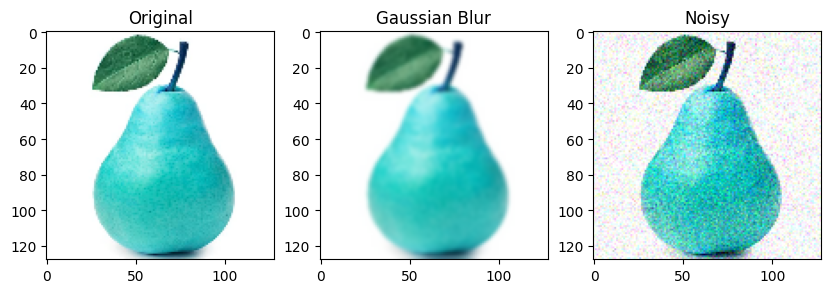

In [ ]:
# Verify Augmented Data
# Plot some images to check augmentations.

plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(train_images[0])

# Blurred image
plt.subplot(1, 3, 2)
plt.title("Gaussian Blur")
plt.imshow(train_blur[0])

# Noisy image
plt.subplot(1, 3, 3)
plt.title("Noisy")
plt.imshow(train_noisy[0])

plt.show()